## Forecasting Noisy Financial Data with Regularized Regression
#### I plan to demonstrate how simple regression models behave on noisy financial series data and how **(L1/L2) penalties** can help in **regularization** if the model were to **overfit**, I'll first prepare the data, then fit **baseline models (OLS)**, and then show **Ridge** (L2) and **Lasso** (L1) regression (and e-net as well). And then we evaluate using rolling-origin cross validation which is a time series-specific technique used to evaluate forecasting models.



[*********************100%***********************]  1 of 1 completed


        Model   Test MSE  Test MAE   Test R2
0         OLS  16.089366  3.051273  0.994935
1       Ridge  16.091566  3.051644  0.994935
2       Lasso  16.065075  3.047655  0.994943
3  ElasticNet  16.126531  3.059227  0.994924


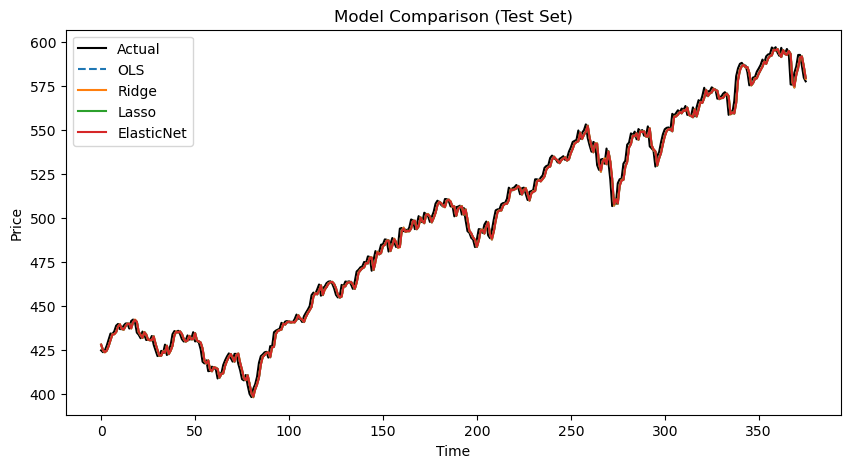

In [6]:
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import matplotlib.pyplot as plt

# 1. Data retrieval (example: Yahoo Finance S&P 500 data)
import yfinance as yf
ticker = 'SPY'  # S&P 500 ETF
data = yf.download(ticker, start="2020-01-01", end="2025-01-01")
df = data[['Close']].copy()
df.dropna(inplace=True)
df = df['Close']  # convert to Series

# 2. Feature engineering: create lag features (lag 1–5)
lags = 5
X = pd.concat([df.shift(i) for i in range(1, lags+1)], axis=1)
X.columns = [f'lag{i}' for i in range(1, lags+1)]
X.dropna(inplace=True)

y = df.loc[X.index] 

# 3. Train/test split
split = int(0.7 * len(X))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# 4. TimeSeriesSplit CV and hyperparameter tuning for Ridge and Lasso
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
ridge_cv = GridSearchCV(Ridge(), param_grid, cv=tscv, scoring='neg_mean_squared_error')
lasso_cv = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=tscv, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
lasso_cv.fit(X_train, y_train)
best_alpha_ridge = ridge_cv.best_params_['alpha']
best_alpha_lasso = lasso_cv.best_params_['alpha']

# 5. Train final models
models = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(alpha=best_alpha_ridge),
    'Lasso': Lasso(alpha=best_alpha_lasso, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=best_alpha_lasso, l1_ratio=0.5, max_iter=10000)
}
for name, model in models.items():
    model.fit(X_train, y_train)

# 6. Evaluate on test set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
results = []
for name, model in models.items():
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    results.append((name, mse, mae, r2))
results_df = pd.DataFrame(results, columns=['Model','Test MSE','Test MAE','Test R2'])
print(results_df)

# 7. Plot actual vs predicted for one model as example
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual', color='black')
plt.plot(models['OLS'].predict(X_test), label='OLS', linestyle='--')
plt.plot(models['Ridge'].predict(X_test), label='Ridge')
plt.plot(models['Lasso'].predict(X_test), label='Lasso')
plt.plot(models['ElasticNet'].predict(X_test), label='ElasticNet')

plt.title("Model Comparison (Test Set)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.savefig('all_models_comparison.png')
plt.show()
